# 03 · Generador simple: perturbación con ruido

**Taller B5-T1 · Generación de datos financieros sintéticos**

El enunciado exige incluir, junto a los tres modelos generativos neuronales, un
cuarto modelo deliberadamente elemental que tome los datos originales y les
anada ruido. Su papel no es competir sino delimitar el terreno: cualquier modelo
neuronal que no consiga superarlo no esta justificando su complejidad.

Conviene tener presente desde el principio cual es la limitación estructural de
este procedimiento. Perturbar una ventana existente produce una variante de un
escenario ya observado, pero **no incrementa el número de escenarios distintos**.
Si el conjunto de partida contiene un ejercicio limitado de episodios de estrés,
al perturbarlo se obtienen muchas copias ligeramente distintas de esos mismos
episodios, no episodios nuevos. Dado que el análisis exploratorio identifico
precisamente la escasez de episodios independientes como el problema de fondo,
cabe esperar que el método aporte poco.

**Salidas:** `models/sinteticos_ruido.npz` y `results/tablas/resultados_ruido.csv`

## Preparación del entorno

Se fija el backend de cómputo, se añade el código común del proyecto a la ruta
de importación y se aplica el estilo gráfico compartido. El bloque funciona sin
cambios tanto en una instalación local como en Colab.

In [1]:
import os
import sys

# Keras 3 se ejecuta sobre PyTorch: la versión de Python empleada no dispone de
# TensorFlow y la API de capas y modelos es idéntica en ambos backends.
os.environ["KERAS_BACKEND"] = "torch"

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    !pip install -q yfinance keras torch
    # En Colab se asume que el repositorio está clonado en el directorio actual.
    RAIZ = "/content/B5-T1"
else:
    RAIZ = os.path.dirname(os.getcwd())

if os.path.join(RAIZ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(RAIZ, "src"))

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from miax_b5t1 import config, datos, experimento, graficos, modelo

graficos.aplicar_estilo()
config.asegurar_directorios()

print(f"Keras {keras.__version__} sobre backend {keras.backend.backend()}")
print(f"Raíz del proyecto: {RAIZ}")

Keras 3.15.1 sobre backend torch
Raíz del proyecto: C:\Users\raulr\Documents\MIAX\Practicas\B5-T1


## 1. Datos de partida

Se carga el dataset y se extrae el presupuesto de datos reales fijado en el
notebook anterior. Es el único material con el que puede trabajar el generador:
utilizar el conjunto de entrenamiento completo le daría acceso a información
vedada al clasificador e invalidaria la comparación.

In [2]:
d = datos.cargar_dataset()

X_real, y_real = datos.submuestra_real(
    d["X_train"], d["y_train"], config.N_REALES, config.SEMILLA)

X_val, y_val = d["X_val"], d["y_val"]
X_test, y_test = d["X_test"], d["y_test"]

print(f"Presupuesto real: {X_real.shape}")
print(f"Positivas: {int(y_real.sum())} ({y_real.mean():.1%})")
print(f"Desviación típica de los datos escalados: {X_real.std():.4f}")

Presupuesto real: (3000, 60, 23)
Positivas: 301 (10.0%)
Desviación típica de los datos escalados: 0.2408


## 2. Definición del generador

El procedimiento consiste en escoger una ventana real al azar y sumarle ruido
gaussiano independiente en cada posición, conservando su etiqueta. La intensidad
del ruido se expresa como fracción de la desviación típica de los datos, de modo
que el parámetro tenga el mismo significado con independencia del escalado
aplicado.

El muestreo de las ventanas de origen se hace por clase, lo que permite fijar la
proporción de positivos del conjunto sintético y establece la analogía con los
generadores condicionales del resto del proyecto.

In [3]:
def generar_por_ruido(X_base, y_base, n_muestras, sigma_rel, proporcion_positivos,
                      semilla=None):
    """Produce muestras perturbando ventanas reales con ruido gaussiano.

    El resultado se recorta al intervalo [-1, 1] para mantenerlo en el mismo
    rango que los datos escalados, condición que también cumplen por
    construcción los generadores con salida tangente hiperbólica.
    """
    rng = np.random.default_rng(config.SEMILLA if semilla is None else semilla)
    sigma = sigma_rel * float(X_base.std())

    n_pos = int(round(n_muestras * proporcion_positivos))
    n_neg = n_muestras - n_pos

    idx_pos = np.where(y_base == 1)[0]
    idx_neg = np.where(y_base == 0)[0]

    selección = np.concatenate([
        rng.choice(idx_pos, size=n_pos, replace=True),
        rng.choice(idx_neg, size=n_neg, replace=True),
    ])
    rng.shuffle(selección)

    X_out = X_base[selección] + rng.normal(0.0, sigma, size=X_base[selección].shape)
    return np.clip(X_out, -1.0, 1.0).astype("float32"), y_base[selección].astype("float32")


print("Generador definido.")

Generador definido.


## 3. Elección de la intensidad del ruido

La intensidad admite dos lecturas opuestas. Un ruido débil produce muestras casi
idénticas a las originales, que no aportan información nueva y equivalen a
repetir el conjunto de entrenamiento. Un ruido intenso destruye la estructura
temporal y de dependencia entre activos, y la muestra deja de parecerse a una
ventana de mercado.

Para elegirlo se examinan tres indicadores en función del parámetro: cuanto se
altera la distribución marginal, cuanto se degrada la correlación entre activos
y cuanta novedad se genera respecto al conjunto de partida.

,sigma relativa,desviación típica,curtosis,error de correlación,distancia media al original
0,0.05,0.2419,2.1872,0.0037,12.3600
1,0.10,0.2427,2.1334,0.0028,12.3822
2,0.25,0.2485,1.8557,0.0124,12.5450
3,0.50,0.2687,1.2059,0.0506,13.1186
4,1.00,0.3375,0.2173,0.1323,15.1805
5,2.00,0.5065,-0.6400,0.2145,20.7027


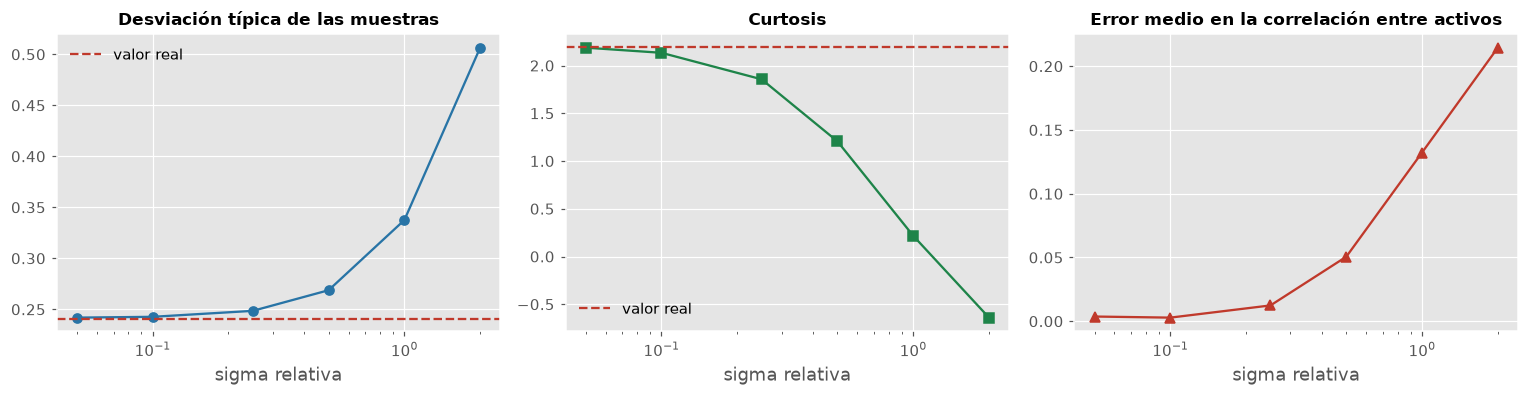

In [4]:
from scipy import stats

sigmas = [0.05, 0.10, 0.25, 0.50, 1.00, 2.00]
corr_real = np.corrcoef(X_real.reshape(-1, X_real.shape[2]).T)
triangulo = np.triu_indices_from(corr_real, k=1)

filas = []
for s in sigmas:
    X_s, y_s = generar_por_ruido(X_real, y_real, 2000, s, config.PROPORCION_POSITIVOS)
    corr_s = np.corrcoef(X_s.reshape(-1, X_s.shape[2]).T)
    filas.append({
        "sigma relativa": s,
        "desviación típica": float(X_s.std()),
        "curtosis": float(stats.kurtosis(X_s.ravel())),
        "error de correlación": float(np.abs(corr_s[triangulo] - corr_real[triangulo]).mean()),
        "distancia media al original": float(
            np.linalg.norm((X_s[:500] - X_real[:1]).reshape(500, -1), axis=1).mean()),
    })

tabla_sigma = pd.DataFrame(filas)
display(tabla_sigma.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.7))
axes[0].plot(tabla_sigma["sigma relativa"], tabla_sigma["desviación típica"],
             marker="o", color="#2874a6")
axes[0].axhline(X_real.std(), color="#c0392b", linestyle="--", label="valor real")
axes[0].set_xscale("log")
axes[0].set_title("Desviación típica de las muestras")
axes[0].set_xlabel("sigma relativa")
axes[0].legend()

axes[1].plot(tabla_sigma["sigma relativa"], tabla_sigma["curtosis"],
             marker="s", color="#1e8449")
axes[1].axhline(stats.kurtosis(X_real.ravel()), color="#c0392b", linestyle="--",
                label="valor real")
axes[1].set_xscale("log")
axes[1].set_title("Curtosis")
axes[1].set_xlabel("sigma relativa")
axes[1].legend()

axes[2].plot(tabla_sigma["sigma relativa"], tabla_sigma["error de correlación"],
             marker="^", color="#c0392b")
axes[2].set_xscale("log")
axes[2].set_title("Error medio en la correlación entre activos")
axes[2].set_xlabel("sigma relativa")

fig.tight_layout()
graficos.guardar(fig, "03_calibracion_sigma")
plt.show()

El comportamiento es el previsto. A partir de una intensidad relativa en torno a
la mitad de la desviación típica de los datos, la varianza de las muestras se
dispara, la curtosis cae hacia el valor gaussiano y la estructura de correlación
entre activos se degrada con rapidez, porque el ruido añadido es independiente
entre series y diluye la dependencia original.

Se adopta una intensidad relativa de **0,25**. Es suficiente para que las
muestras no sean copias literales y lo bastante contenida para preservar el
grueso de la estructura. La elección se documenta explícitamente porque
condiciona el resultado del modelo.

In [5]:
SIGMA_RELATIVA = 0.25
N_SINTETICOS = int(config.N_REALES * max(config.RATIOS_SINTETICOS))

X_synth, y_synth = generar_por_ruido(
    X_real, y_real, N_SINTETICOS, SIGMA_RELATIVA,
    config.PROPORCION_POSITIVOS, semilla=config.SEMILLA)

print(f"Muestras sintéticas generadas: {X_synth.shape}")
print(f"Positivas: {int(y_synth.sum())} ({y_synth.mean():.1%})")
print(f"Rango: [{X_synth.min():.3f}, {X_synth.max():.3f}]")

Muestras sintéticas generadas: (12000, 60, 23)
Positivas: 1200 (10.0%)
Rango: [-1.000, 1.000]


## 4. Curva de convergencia

Este modelo no tiene parámetros que ajustar y por tanto carece de proceso
iterativo de entrenamiento. En lugar de una curva de pérdida se documenta la
magnitud que hace las veces de criterio de diseño: el error cometido en la
reproducción de la estructura de correlación en función de la intensidad del
ruido, que es lo que ha guiado la elección del parámetro.

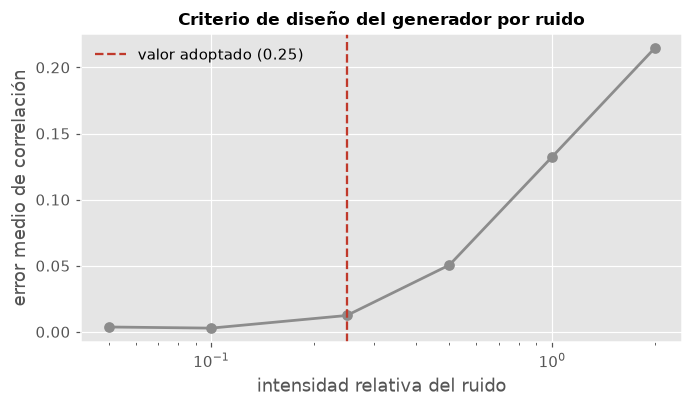

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(tabla_sigma["sigma relativa"], tabla_sigma["error de correlación"],
        marker="o", color="#8c8c8c", linewidth=1.8)
ax.axvline(SIGMA_RELATIVA, color="#c0392b", linestyle="--",
           label=f"valor adoptado ({SIGMA_RELATIVA})")
ax.set_xscale("log")
ax.set_xlabel("intensidad relativa del ruido")
ax.set_ylabel("error medio de correlación")
ax.set_title("Criterio de diseño del generador por ruido")
ax.legend()
fig.tight_layout()
graficos.guardar(fig, "03_criterio_diseno")
plt.show()

## 5. Validación cualitativa

Se contrastan las muestras generadas con las reales en los tres aspectos que el
análisis exploratorio señaló como determinantes: forma de las trayectorias,
distribución marginal y estructura de dependencia entre activos.

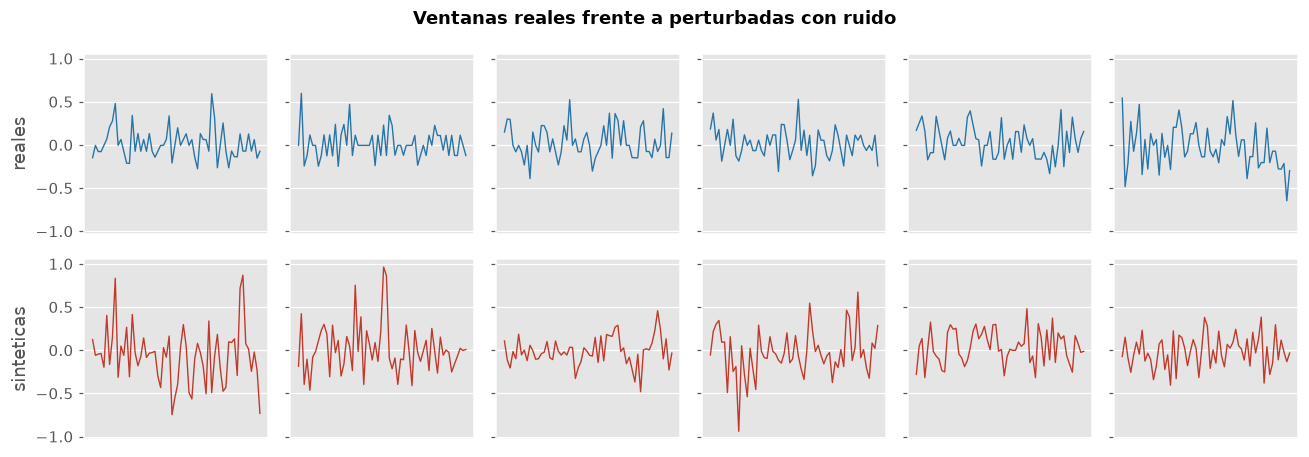

In [7]:
graficos.comparar_trayectorias(
    X_real, X_synth, "Ventanas reales frente a perturbadas con ruido",
    "03_trayectorias")
plt.show()

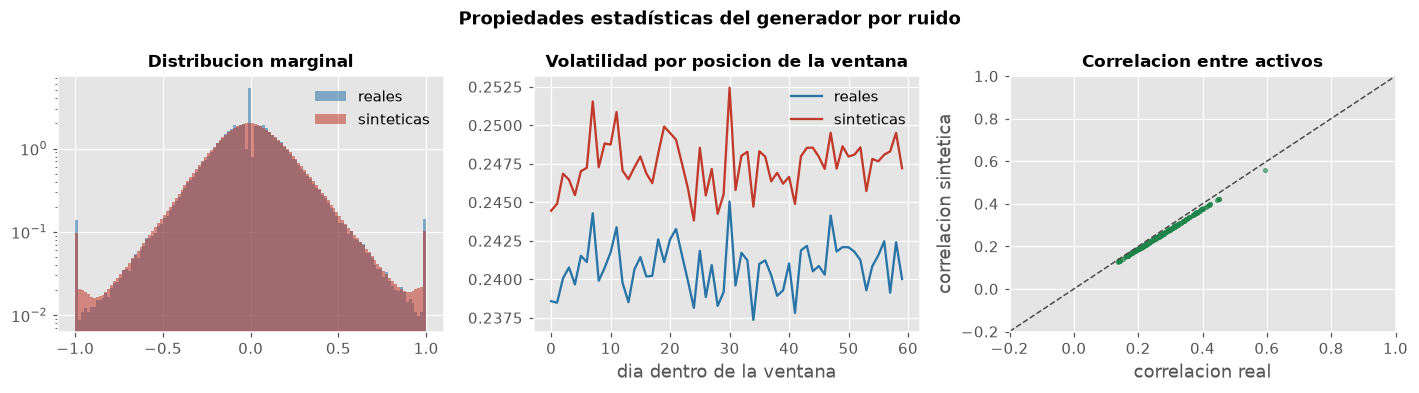

In [8]:
graficos.comparar_distribuciones(
    X_real, X_synth, "Propiedades estadísticas del generador por ruido",
    "03_distribuciones")
plt.show()

Las trayectorias son indistinguibles a simple vista de las originales, lo que era
esperable: son las originales con una perturbación moderada. La distribución
marginal se ensancha ligeramente y la correlación entre activos se desplaza de
forma sistemática hacia valores algo menores, efecto directo de sumar ruido
independiente a series correlacionadas.

### Novedad respecto al conjunto de partida

La prueba decisiva para este generador es cuanta información realmente nueva
aporta. Se mide la distancia de cada muestra sintética a la ventana real más
próxima y se compara con la distancia típica entre dos ventanas reales distintas.

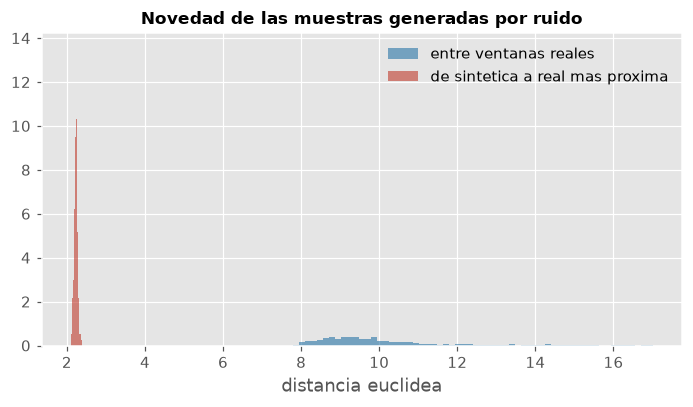

distancia_media_sintetica: 2.2309
distancia_media_real: 10.0454
ratio: 0.2221


In [9]:
fig, ax, resumen_novedad = graficos.novedad_vecino_mas_cercano(
    X_real, X_synth, "Novedad de las muestras generadas por ruido",
    "03_novedad")
plt.show()

for clave, valor in resumen_novedad.items():
    print(f"{clave}: {valor:.4f}")

El resultado cuantifica la limitación anticipada al comienzo. Las muestras
sintéticas se sitúan sistemáticamente mucho más cerca de alguna ventana real que
lo que dos ventanas reales distintas lo estan entre si. El generador no explora
regiones nuevas del espacio: se limita a poblar densamente el entorno inmediato
de los datos que ya tiene.

Para un clasificador esto equivale, en el mejor de los casos, a una forma de
regularización por aumento de datos. Puede reducir el sobreajuste, pero no puede
ensenar ningún escenario de mercado que no estuviera ya presente.

## 6. Evaluación

Se ejecuta el protocolo común: se entrena el clasificador con el presupuesto real
más cantidades crecientes de sintéticos, y se mide sobre el conjunto de test.

In [10]:
resultados_ruido, historias_ruido = experimento.barrido_ratios(
    "ruido", X_real, y_real, X_synth, y_synth, X_val, y_val, X_test, y_test)

experimento.guardar_sinteticos(
    "ruido", X_synth, y_synth,
    perdidas={"error_correlación": tabla_sigma["error de correlación"].values})
ruta = experimento.guardar_resultados(resultados_ruido, "ruido")
print(f"\nResultados guardados en {ruta}")

resumen_ruido = experimento.resumir(resultados_ruido)
display(resumen_ruido.round(4))

  ruido      ratio=0.00  semilla=42 PR-AUC(test)=0.3372 PR-AUC(val)=0.3276 F1=0.2755


  ruido      ratio=0.00  semilla=43 PR-AUC(test)=0.2906 PR-AUC(val)=0.3649 F1=0.2970


  ruido      ratio=0.00  semilla=44 PR-AUC(test)=0.1680 PR-AUC(val)=0.3235 F1=0.1887


  ruido      ratio=0.00  semilla=45 PR-AUC(test)=0.1158 PR-AUC(val)=0.3074 F1=0.1732


  ruido      ratio=0.00  semilla=46 PR-AUC(test)=0.3101 PR-AUC(val)=0.3281 F1=0.2566


...

  ruido      ratio=4.00  semilla=44 PR-AUC(test)=0.1394 PR-AUC(val)=0.2385 F1=0.1199


  ruido      ratio=4.00  semilla=45 PR-AUC(test)=0.1322 PR-AUC(val)=0.3111 F1=0.1838


  ruido      ratio=4.00  semilla=46 PR-AUC(test)=0.1479 PR-AUC(val)=0.2784 F1=0.1877



Resultados guardados en C:\Users\raulr\Documents\MIAX\Practicas\B5-T1\results\tablas\resultados_ruido.csv


,modelo,ratio,pr_auc_media,pr_auc_std,pr_auc_val_media,pr_auc_val_std,f1_media,f1_std,recall_media,precision_media,n_sinteticos
0,ruido,0.00,0.2443,0.0967,0.3303,0.0211,0.2382,0.0544,0.2790,0.2701,0
1,ruido,0.25,0.2585,0.0697,0.3304,0.0242,0.2639,0.0377,0.3514,0.2697,750
2,ruido,0.50,0.2023,0.0481,0.3017,0.0345,0.1944,0.0511,0.3029,0.1622,1500
3,ruido,1.00,0.2335,0.0660,0.3141,0.0259,0.2254,0.0978,0.3753,0.2017,3000
4,ruido,2.00,0.1801,0.0768,0.2986,0.0321,0.1793,0.0798,0.2535,0.1519,6000
5,ruido,4.00,0.1380,0.0139,0.2764,0.0274,0.1833,0.0379,0.2889,0.1462,12000


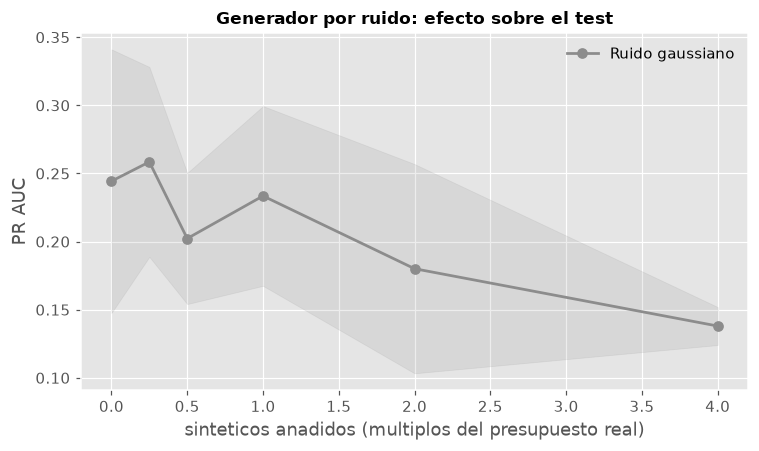

PR-AUC sin sintéticos:    0.2443
Mejor PR-AUC:             0.2585 con ratio 0.25
Variación:                +5.8 %


In [11]:
graficos.curva_ratios(
    resumen_ruido, titulo="Generador por ruido: efecto sobre el test",
    nombre_fichero="03_curva_ratios")
plt.show()

base = resumen_ruido.loc[resumen_ruido["ratio"] == 0.0, "pr_auc_media"].iloc[0]
mejor = resumen_ruido.loc[resumen_ruido["pr_auc_media"].idxmax()]

print(f"PR-AUC sin sintéticos:    {base:.4f}")
print(f"Mejor PR-AUC:             {mejor['pr_auc_media']:.4f} "
      f"con ratio {mejor['ratio']:g}")
print(f"Variación:                {100 * (mejor['pr_auc_media'] - base) / base:+.1f} %")

Las curvas de pérdida de cada entrenamiento del clasificador documentan la
convergencia exigida por el enunciado. Se representan agrupadas por ratio.

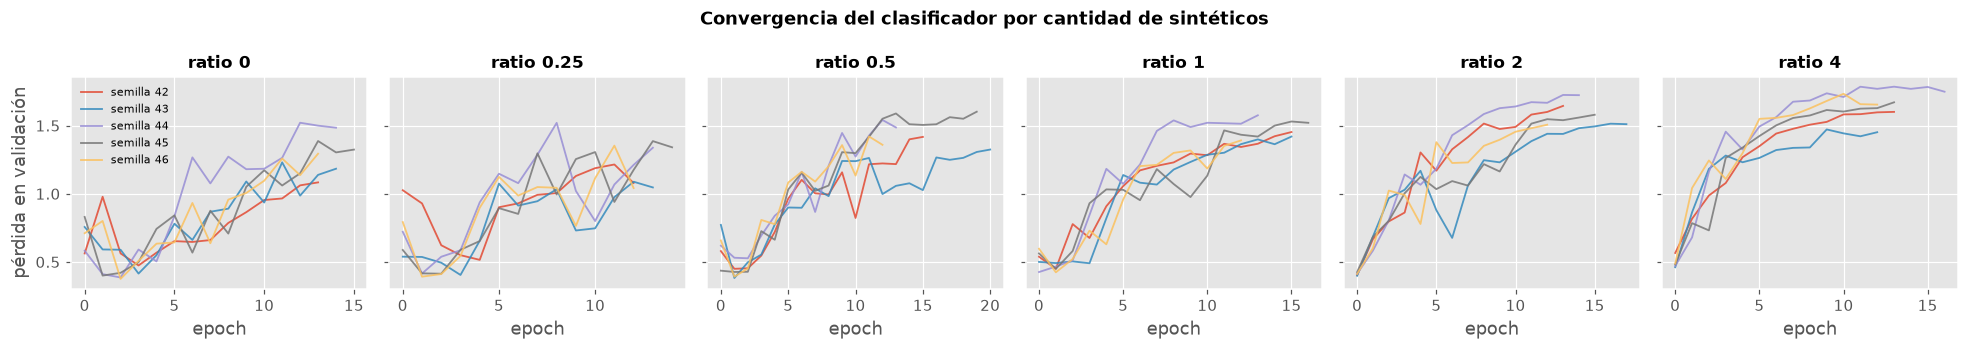

In [12]:
ratios_mostrados = sorted({r for r, _ in historias_ruido})
fig, axes = plt.subplots(1, len(ratios_mostrados),
                         figsize=(3.0 * len(ratios_mostrados), 3.2), sharey=True)
axes = np.atleast_1d(axes)

for ax, ratio in zip(axes, ratios_mostrados):
    for (r, semilla), historia in historias_ruido.items():
        if r == ratio:
            ax.plot(historia["val_loss"], linewidth=1.2, alpha=0.85,
                    label=f"semilla {semilla}")
    ax.set_title(f"ratio {ratio:g}")
    ax.set_xlabel("epoch")

axes[0].set_ylabel("pérdida en validación")
axes[0].legend(fontsize=7)
fig.suptitle("Convergencia del clasificador por cantidad de sintéticos",
             fontweight="bold")
fig.tight_layout()
graficos.guardar(fig, "03_perdidas_clasificador")
plt.show()

## Conclusiones del notebook

1. **El generador reproduce fielmente las propiedades locales de los datos** por
   la razón trivial de que parte de ellos. Distribución marginal y forma de las
   trayectorias se conservan; la correlación entre activos se degrada de forma
   leve pero sistemática, porque el ruido añadido es independiente entre series.
2. **No aporta escenarios nuevos.** La distancia al vecino real más próximo es
   muy inferior a la distancia típica entre ventanas reales, lo que confirma que
   las muestras son variantes locales de las existentes y no configuraciones de
   mercado distintas.
3. **Su efecto sobre el clasificador es el de una regularización suave.** Puede
   amortiguar el sobreajuste, pero no puede resolver la carencia identificada en
   el análisis exploratorio, que es la escasez de episodios de estrés
   independientes.
4. **Queda fijado el nivel mínimo exigible.** Un modelo generativo neuronal que
   no supere a este procedimiento no esta aprovechando su capacidad para
   representar la distribución de los datos, y su complejidad no queda
   justificada.